<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/62_Lab2_Forecast_Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2. Forecast → Portfolio / Optimization
### 예측에서 포트폴리오 최적화로 / From Forecast to Portfolio Optimization

이 실습은 금융 시계열을 사용하여 **예측 기반 자산배분**을 수행합니다.  
This lab uses financial time-series data to conduct **forecast-driven asset allocation**.

---
**학습목표 / Learning Objectives**
1. 공개 금융데이터를 수집한다.  
   Collect public financial data.
2. 단순한 수익률 예측을 기대수익으로 변환한다.  
   Convert simple return forecasts into expected returns.
3. 장기투자 관점에서 포트폴리오 최적화를 수행한다.  
   Perform portfolio optimization from a long-horizon perspective.
4. Equal Weight와 Forecast-Driven Portfolio를 비교한다.  
   Compare Equal Weight and Forecast-Driven Portfolio.

In [1]:
# Colab 권장 설치 셀 / Recommended installation cell
!pip -q install yfinance statsmodels scipy openpyxl

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import display, Markdown

np.random.seed(42)


def bilingual_title(kr, en):
    display(Markdown(f"## {kr}<br><span style='font-size:0.9em;color:#666'>{en}</span>"))


def bilingual_text(kr, en):
    display(Markdown(f"**[KR]** {kr}<br>**[EN]** {en}"))


def summary_box(title_kr, title_en, bullets_kr, bullets_en):
    kr = '<br>'.join([f"- {x}" for x in bullets_kr])
    en = '<br>'.join([f"- {x}" for x in bullets_en])
    display(Markdown(f"### {title_kr}<br><span style='font-size:0.9em;color:#666'>{title_en}</span><br><br>**[KR]**<br>{kr}<br><br>**[EN]**<br>{en}"))

In [3]:
bilingual_title("1. 데이터 수집", "1. Download market data")

import yfinance as yf

tickers = ['SPY', 'TLT', 'GLD', 'QQQ']
start_date = '2018-01-01'
end_date = '2026-09-10'

try:
    prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)['Close']
    prices = prices.dropna()
    data_source = 'yfinance'
except Exception as e:
    data_source = 'synthetic'
    dates = pd.date_range('2018-01-31', '2026-08-31', freq='M')
    rng = np.random.default_rng(42)
    returns_syn = pd.DataFrame({
        'SPY': rng.normal(0.008, 0.04, len(dates)),
        'TLT': rng.normal(0.003, 0.03, len(dates)),
        'GLD': rng.normal(0.004, 0.035, len(dates)),
        'QQQ': rng.normal(0.010, 0.06, len(dates)),
    }, index=dates)
    prices = 100 * (1 + returns_syn).cumprod()

monthly_prices = prices.resample('M').last()
rets = monthly_prices.pct_change().dropna()

display(monthly_prices.tail())
bilingual_text(
    f"데이터 원천: {data_source}. 사용 자산은 {', '.join(tickers)} 입니다.",
    f"Data source: {data_source}. Assets used: {', '.join(tickers)}."
)

## 1. 데이터 수집<br><span style='font-size:0.9em;color:#666'>1. Download market data</span>

Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-05-31,417.119995,737.499512,754.536133,84.444611
2026-06-30,368.380005,736.400024,746.770020,85.429184
2026-07-31,371.540009,687.989990,747.030029,81.607285
2026-08-31,408.420013,716.760010,767.049988,82.204994
2026-09-30,403.350006,716.309998,762.400024,81.730003


**[KR]** 데이터 원천: yfinance. 사용 자산은 SPY, TLT, GLD, QQQ 입니다.<br>**[EN]** Data source: yfinance. Assets used: SPY, TLT, GLD, QQQ.

In [4]:
bilingual_title("2. 기대수익 예측", "2. Forecast expected returns")

# 6개월 rolling mean을 다음 달 기대수익으로 사용
exp_ret = rets.rolling(6).mean().shift(1).dropna()
common_index = exp_ret.index.intersection(rets.index)
exp_ret = exp_ret.loc[common_index]
rets = rets.loc[common_index]

display(exp_ret.tail())
bilingual_text(
    "이번 실습에서는 복잡한 예측모형 대신 최근 6개월 평균수익률을 다음 달 기대수익으로 사용합니다.",
    "In this lab, instead of a complex forecasting model, we use the 6-month rolling mean return as the expected return for the next month."
)

## 2. 기대수익 예측<br><span style='font-size:0.9em;color:#666'>2. Forecast expected returns</span>

Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-05-31,0.026571,0.012512,0.010753,-0.004761
2026-06-30,0.015052,0.032727,0.019199,-0.004326
2026-07-31,-0.008045,0.033596,0.017350,0.002048
2026-08-31,-0.027071,0.020588,0.014952,-0.005351
2026-09-30,-0.025061,0.031465,0.020859,-0.011853


**[KR]** 이번 실습에서는 복잡한 예측모형 대신 최근 6개월 평균수익률을 다음 달 기대수익으로 사용합니다.<br>**[EN]** In this lab, instead of a complex forecasting model, we use the 6-month rolling mean return as the expected return for the next month.

In [5]:
bilingual_title("3. 포트폴리오 최적화 함수", "3. Define portfolio optimization")

def portfolio_perf(weights, mu, cov):
    ret = np.dot(weights, mu)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    return ret, vol

def neg_sharpe(weights, mu, cov, rf=0.0):
    ret, vol = portfolio_perf(weights, mu, cov)
    return -(ret - rf) / (vol + 1e-8)

def optimize_weights(mu, cov, max_weight=0.7):
    n = len(mu)
    x0 = np.repeat(1/n, n)
    bounds = tuple((0, max_weight) for _ in range(n))
    constraints = ({'type':'eq', 'fun': lambda w: np.sum(w)-1})
    result = minimize(neg_sharpe, x0=x0, args=(mu, cov), method='SLSQP', bounds=bounds, constraints=constraints)
    if result.success:
        return result.x
    return x0

## 3. 포트폴리오 최적화 함수<br><span style='font-size:0.9em;color:#666'>3. Define portfolio optimization</span>

## 4. Walk-forward 백테스트<br><span style='font-size:0.9em;color:#666'>4. Walk-forward backtest</span>

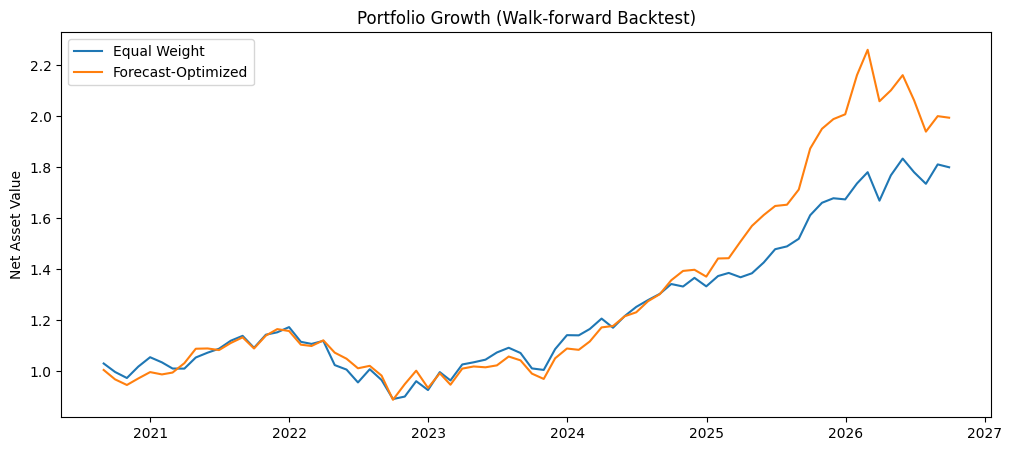

In [6]:
bilingual_title("4. Walk-forward 백테스트", "4. Walk-forward backtest")

lookback_cov = 24
idx = exp_ret.index[lookback_cov:]

ew_returns = []
opt_returns = []
opt_weights = []

for t in idx:
    hist = rets.loc[:t].iloc[:-1].tail(lookback_cov)
    mu = exp_ret.loc[t].values
    cov = hist.cov().values

    w_ew = np.repeat(1/len(tickers), len(tickers))
    w_opt = optimize_weights(mu, cov, max_weight=0.7)

    realized = rets.loc[t].values
    ew_returns.append(np.dot(w_ew, realized))
    opt_returns.append(np.dot(w_opt, realized))
    opt_weights.append(w_opt)

bt = pd.DataFrame({
    'EqualWeight': ew_returns,
    'ForecastOptimized': opt_returns
}, index=idx)

wdf = pd.DataFrame(opt_weights, index=idx, columns=tickers)
nav = (1 + bt).cumprod()

plt.figure(figsize=(12,5))
plt.plot(nav.index, nav['EqualWeight'], label='Equal Weight')
plt.plot(nav.index, nav['ForecastOptimized'], label='Forecast-Optimized')
plt.title('Portfolio Growth (Walk-forward Backtest)')
plt.ylabel('Net Asset Value')
plt.legend()
plt.show()

In [7]:
bilingual_title("5. 성과지표 계산", "5. Compute performance metrics")

def performance_summary(series):
    n = len(series)
    cagr = (1 + series).prod() ** (12/n) - 1
    vol = series.std() * np.sqrt(12)
    sharpe = series.mean() / (series.std() + 1e-8) * np.sqrt(12)
    nav = (1 + series).cumprod()
    mdd = (nav / nav.cummax() - 1).min()
    return pd.Series({'CAGR': cagr, 'Volatility': vol, 'Sharpe': sharpe, 'MDD': mdd})

perf = pd.concat([
    performance_summary(bt['EqualWeight']).rename('EqualWeight'),
    performance_summary(bt['ForecastOptimized']).rename('ForecastOptimized')
], axis=1).T

display(perf)

bilingual_text(
    "성과 비교표를 바탕으로 예측 기반 최적화가 단순 균등가중보다 나은지 평가합니다.",
    "Use the performance table to evaluate whether forecast-driven optimization outperforms simple equal weighting."
)

## 5. 성과지표 계산<br><span style='font-size:0.9em;color:#666'>5. Compute performance metrics</span>

,CAGR,Volatility,Sharpe,MDD
EqualWeight,0.100029,0.124416,0.830840,-0.240147
ForecastOptimized,0.118461,0.134754,0.901398,-0.237467


**[KR]** 성과 비교표를 바탕으로 예측 기반 최적화가 단순 균등가중보다 나은지 평가합니다.<br>**[EN]** Use the performance table to evaluate whether forecast-driven optimization outperforms simple equal weighting.

## 6. 드로우다운과 가중치<br><span style='font-size:0.9em;color:#666'>6. Drawdown and portfolio weights</span>

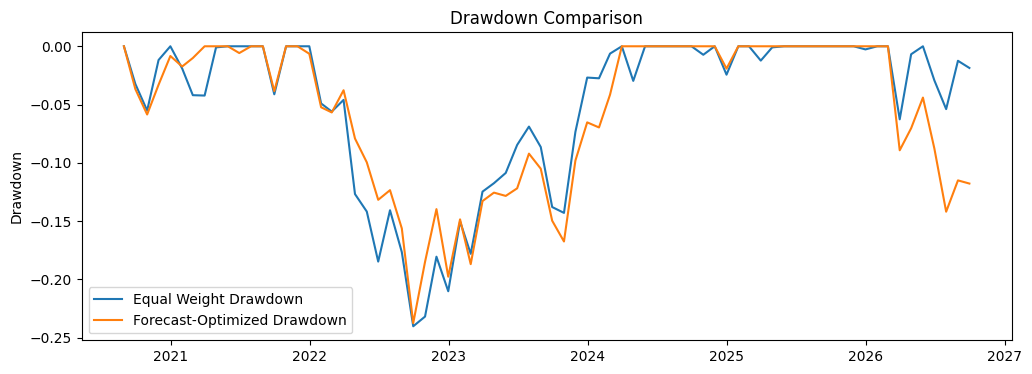

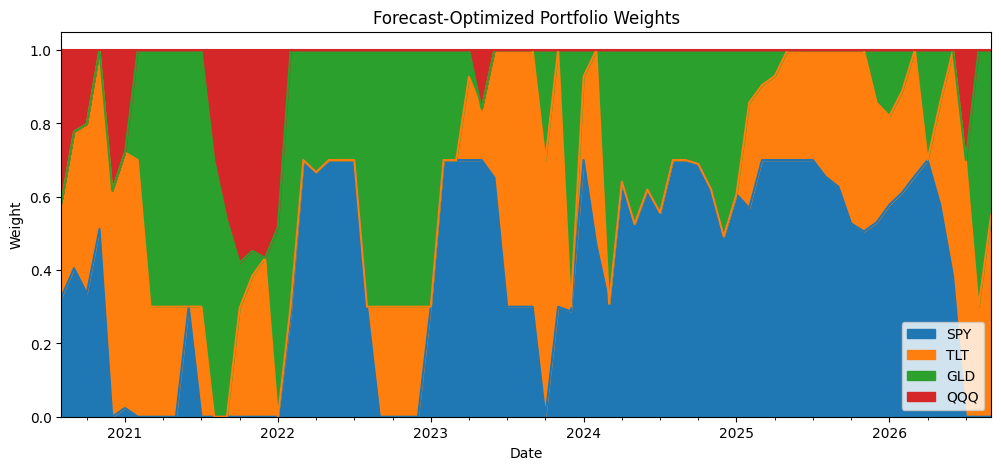

In [8]:
bilingual_title("6. 드로우다운과 가중치", "6. Drawdown and portfolio weights")

dd = nav.div(nav.cummax()).sub(1)

plt.figure(figsize=(12,4))
plt.plot(dd.index, dd['EqualWeight'], label='Equal Weight Drawdown')
plt.plot(dd.index, dd['ForecastOptimized'], label='Forecast-Optimized Drawdown')
plt.title('Drawdown Comparison')
plt.ylabel('Drawdown')
plt.legend()
plt.show()

wdf.plot(kind='area', stacked=True, figsize=(12,5))
plt.title('Forecast-Optimized Portfolio Weights')
plt.ylabel('Weight')
plt.show()

In [9]:
bilingual_title("7. 결과 해석", "7. Interpretation")

better = perf['CAGR'].idxmax()
lower_risk = perf['Volatility'].idxmin()

bilingual_text(
    f"누적성과(CAGR) 기준 더 우수한 전략은 {better}입니다. 변동성 기준 더 안정적인 전략은 {lower_risk}입니다.",
    f"The strategy with higher CAGR is {better}. The strategy with lower volatility is {lower_risk}."
)

summary_box(
    "핵심 해석",
    "Key Interpretation",
    [
        "예측은 기대수익 추정치로 사용된다.",
        "최적화는 기대수익과 공분산을 함께 반영한다.",
        "성과 비교는 누적수익뿐 아니라 변동성·샤프·MDD를 함께 봐야 한다."
    ],
    [
        "Forecasts are used as expected return estimates.",
        "Optimization reflects both expected returns and covariance.",
        "Performance should be judged by return, volatility, Sharpe ratio, and maximum drawdown together."
    ]
)

## 7. 결과 해석<br><span style='font-size:0.9em;color:#666'>7. Interpretation</span>

**[KR]** 누적성과(CAGR) 기준 더 우수한 전략은 ForecastOptimized입니다. 변동성 기준 더 안정적인 전략은 EqualWeight입니다.<br>**[EN]** The strategy with higher CAGR is ForecastOptimized. The strategy with lower volatility is EqualWeight.

### 핵심 해석<br><span style='font-size:0.9em;color:#666'>Key Interpretation</span><br><br>**[KR]**<br>- 예측은 기대수익 추정치로 사용된다.<br>- 최적화는 기대수익과 공분산을 함께 반영한다.<br>- 성과 비교는 누적수익뿐 아니라 변동성·샤프·MDD를 함께 봐야 한다.<br><br>**[EN]**<br>- Forecasts are used as expected return estimates.<br>- Optimization reflects both expected returns and covariance.<br>- Performance should be judged by return, volatility, Sharpe ratio, and maximum drawdown together.

## 학생용 질문 / Questions for Students
1. 기대수익을 6개월 이동평균 대신 ARIMA 예측치로 바꾸면 결과가 달라질까요?  
   How might results change if you replace the 6-month rolling mean with ARIMA forecasts?
2. 최대 자산비중 제약(0.7)을 더 엄격하게 하면 어떤 변화가 생길까요?  
   What happens if the maximum weight constraint (0.7) becomes more restrictive?
3. 예측오차가 큰 자산을 포트폴리오에서 어떻게 다뤄야 할까요?  
   How should assets with large forecast error be handled in the portfolio?